In [ ]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
print(df.shape)

print(df.columns)

print(df['Category'].value_counts())

(2484, 4)
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [7]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to C:\Users\Ankita
[nltk_data]     Roy\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\Ankita
[nltk_data]     Roy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Ankita
[nltk_data]     Roy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_resume(text):

    text = text.lower()

    text = re.sub(r'http\S+', ' ', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    words = nltk.word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [9]:
df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)

In [10]:
df[['Resume_str', 'cleaned_resume']].head()

,Resume_str,cleaned_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist u hr operation summary versatile...
2,HR DIRECTOR Summary Over 2...,hr director summary year experience recruiting...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlight hr skill hr departm...


In [11]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_resume'])

In [12]:
kmeans = KMeans(n_clusters=25, random_state=42)

kmeans.fit(X)

df['Cluster'] = kmeans.labels_

C:\Users\Ankita Roy\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Ankita Roy\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Ankita Roy\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Ankita Roy\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~

In [13]:
df[['Category', 'Cluster']].head(20)

,Category,Cluster
0,HR,1
1,HR,10
2,HR,15
3,HR,12
4,HR,15
5,HR,12
6,HR,15
7,HR,15
8,HR,20
9,HR,15


In [14]:
skills = [
    'python',
    'sql',
    'machine learning',
    'excel',
    'java',
    'power bi',
    'tableau',
    'communication',
    'deep learning',
    'data analysis'
]

In [15]:
def extract_skills(text):

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

In [16]:
df['Skills'] = df['cleaned_resume'].apply(extract_skills)

df[['Category', 'Skills']].head()

,Category,Skills
0,HR,[data analysis]
1,HR,[communication]
2,HR,[excel]
3,HR,"[excel, communication]"
4,HR,[excel]


In [17]:
job_description = """
Python SQL Machine Learning Data Analysis
"""

In [18]:
job_vector = tfidf.transform([job_description])

In [19]:
scores = cosine_similarity(X, job_vector)

In [20]:
df['Score'] = scores * 10

df['Score'] = df['Score'].round(2)

In [21]:
top_resumes = df.sort_values(by='Score', ascending=False)

top_resumes[['Category', 'Score', 'Skills']].head(10)

,Category,Score,Skills
1762,ENGINEERING,3.15,"[python, sql, machine learning, excel, tableau..."
1142,CONSULTANT,2.93,"[sql, excel, java, tableau, communication]"
1218,CONSULTANT,2.87,"[python, sql, machine learning, java, data ana..."
2153,BANKING,2.46,"[python, sql, machine learning]"
1339,AUTOMOBILE,2.44,"[python, sql, excel, tableau, data analysis]"
1303,DIGITAL-MEDIA,2.31,"[python, sql, excel, java, power bi, tableau]"
926,AGRICULTURE,2.11,"[python, sql, excel, java, tableau, communicat..."
1348,AUTOMOBILE,2.10,"[python, sql, machine learning, excel, java, d..."
243,INFORMATION-TECHNOLOGY,2.09,"[sql, tableau]"
2184,BANKING,1.97,"[sql, java, communication, data analysis]"


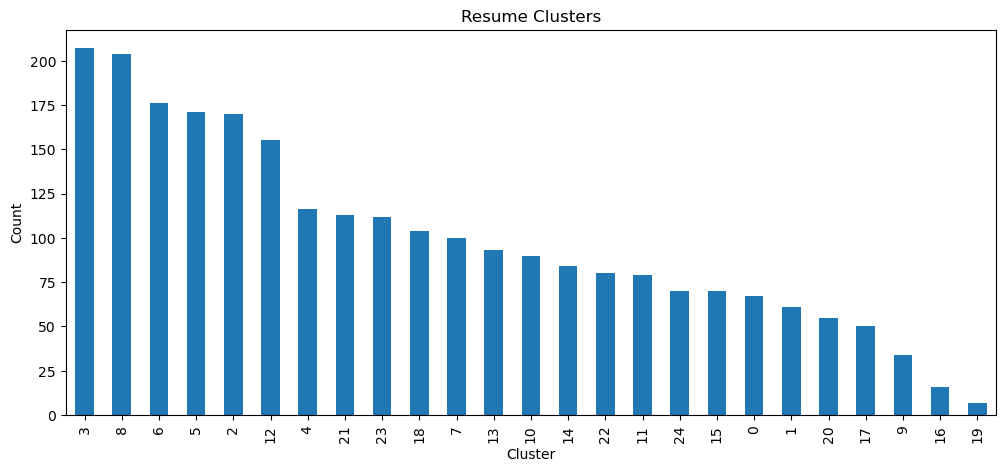

In [22]:
plt.figure(figsize=(12,5))

df['Cluster'].value_counts().plot(kind='bar')

plt.title("Resume Clusters")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()

In [25]:
pip install PyPDF2

Note: you may need to restart the kernel to use updated packages.


In [4]:
import PyPDF2

def extract_text_from_pdf(pdf_path):

    text = ""

    with open(pdf_path, 'rb') as file:

        reader = PyPDF2.PdfReader(file)

        for page in reader.pages:

            text += page.extract_text()

    return text

In [5]:
resume_text = extract_text_from_pdf("Ankita_Roy_Resume.pdf")

print(resume_text[:1000])

ANKITA ROY  
+91-9828758568 | ankitaroy0807@gmail.com  | LinkedIn  | GitHub  
 
PROFESSIONAL SUMMARY  
Junior Data Analyst with strong hands -on experience in SQL, Power BI, Advanced Excel, and Python. Skilled in analyzing 
structured business data, building interactive dashboards, and delivering actionable insights for business . Actively seeking Junior 
Data Analyst / Business Analyst roles in analytics -driven organizations.  
 
CORE SKILLS  
SQL | Power  BI | Advanced  Excel  | Python  | Data Cleaning | Exploratory Data Analysis | KPI Analysis | Dashboarding |  Business 
Reporting  
 
TECHNICAL SKILLS  
Programming & Analysis: SQL (MySQL), Python  
Visualization  Tools:  Power  BI, Tableau,  Excel   
Tools & Platforms: Jupyter Notebook, VS Code, GitHub  
 
EXPERIENCE  
Data Analyst – SkilloVilla (Project Experience) | Feb 2025 – Jul 2025  
• Analyzed  sales and operations datasets using SQL, Excel, and Python to support business reporting and performance analysis.  
• Designed  Pow

In [6]:
skills_db = [
    'python',
    'sql',
    'excel',
    'machine learning',
    'power bi',
    'tableau',
    'deep learning',
    'java',
    'communication',
    'data analysis',
    'aws',
    'cloud',
    'nlp'
]

In [7]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills_db:

        if skill.lower() in text:

            found_skills.append(skill)

    return found_skills

In [8]:
skills = extract_skills(resume_text)

print(skills)

['python', 'sql', 'excel', 'power bi', 'tableau', 'data analysis', 'aws']


In [10]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Job description
job_description = """
Looking for Python, SQL,
Machine Learning, Power BI,
Data Analysis skills
"""

# Convert text into embeddings
resume_embedding = model.encode(resume_text)

job_embedding = model.encode(job_description)

# Semantic similarity
similarity = cosine_similarity(
    [resume_embedding],
    [job_embedding]
)[0][0]

# Skill matching
job_skills = [
    'python',
    'sql',
    'machine learning',
    'power bi',
    'data analysis'
]

matched_skills = 0

for skill in job_skills:

    if skill in skills:

        matched_skills += 1

skill_score = (
    matched_skills / len(job_skills)
) * 100

# Final ATS Score
final_ats_score = (
    (skill_score * 0.5)
    +
    (similarity * 100 * 0.5)
)

print("Skill Score:", round(skill_score, 2))

print("Similarity Score:", round(similarity * 100, 2))

print("Final ATS Score:", round(final_ats_score, 2))

if final_ats_score >= 85:
    print("Excellent Match")

elif final_ats_score >= 70:
    print("Good Match")

elif final_ats_score >= 50:
    print("Average Match")

else:
    print("Low Match")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Skill Score: 80.0
Similarity Score: 59.56
Final ATS Score: 69.78
Average Match
